Rows, cols: (301, 9)
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   P

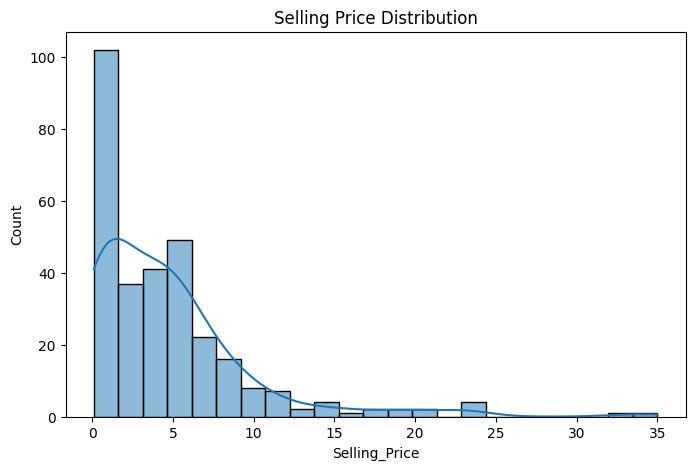

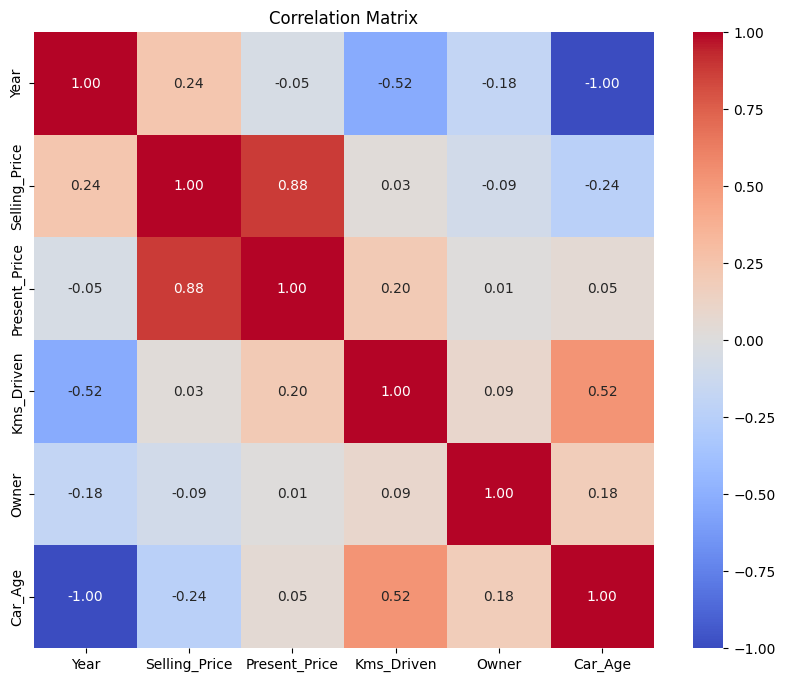

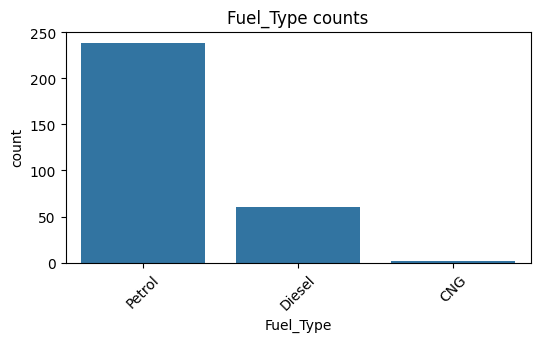

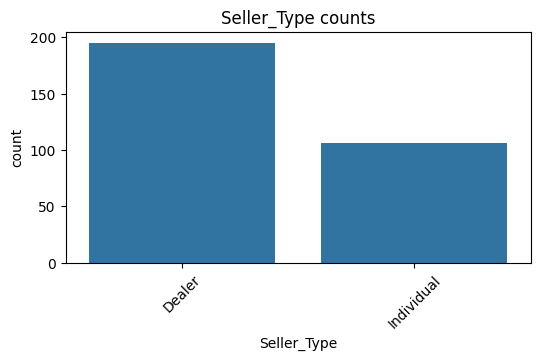

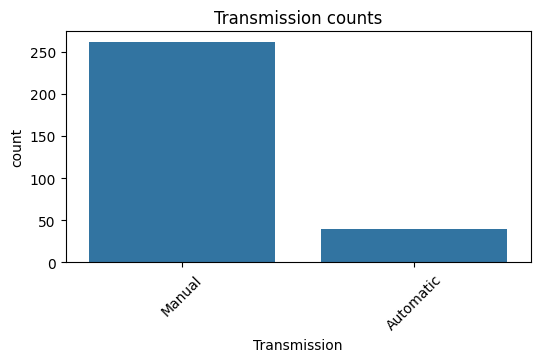

RMSE: 1.091, R2: 0.948


<Figure size 1000x600 with 0 Axes>

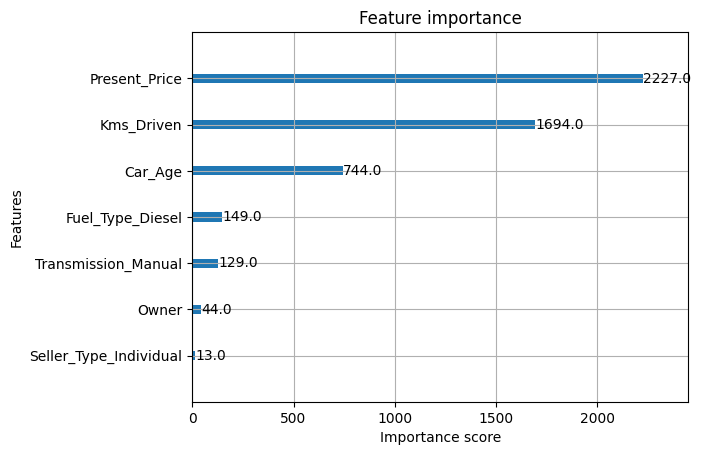

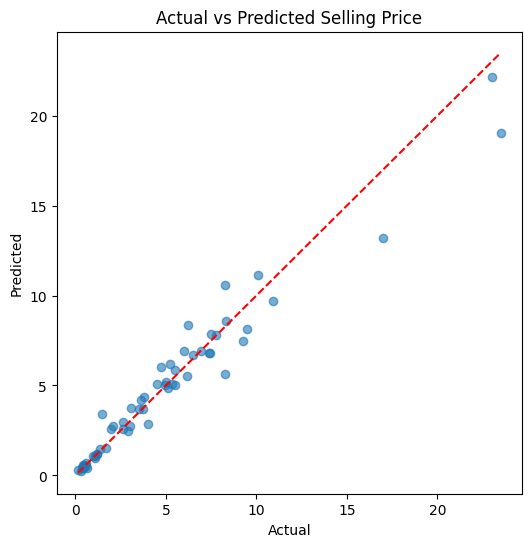

Model saved to car_xgb_model.pkl


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import joblib

# Load Dataset
df = pd.read_csv('car_prediction_data.csv')

# Basic EDA
print('Rows, cols:', df.shape)
print(df.head())
print(df.info())
print(df.describe())
print('Missing values:\n', df.isnull().sum())

# Feature engineering: compute car age
df['Car_Age'] = pd.Timestamp.now().year - df['Year']

# Visualizations: target distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Selling_Price'], kde=True)
plt.title('Selling Price Distribution')
plt.show()

# Correlation heatmap for numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Categorical counts
cat_cols = ['Fuel_Type','Seller_Type','Transmission']
for c in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=c)
    plt.title(f'{c} counts')
    plt.xticks(rotation=45)
    plt.show()

# Prepare data for modeling
X = df.drop(columns=['Car_Name','Year','Selling_Price'])
y = df['Selling_Price']

# One-hot encode categorical features
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost regressor
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)

# Train Random Forest regressor
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate XGBoost
y_pred_xgb = xgb_model.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# Evaluate Random Forest
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'XGBoost RMSE: {rmse_xgb:.3f}, R2: {r2_xgb:.3f}')
print(f'Random Forest RMSE: {rmse_rf:.3f}, R2: {r2_rf:.3f}')

# Compare model performance
results = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest'],
    'RMSE': [rmse_xgb, rmse_rf],
    'R2': [r2_xgb, r2_rf]
})
print('\nComparison:')
print(results)

plt.figure(figsize=(8,4))
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=results_melted, x='Metric', y='Score', hue='Model')
plt.title('Model Performance Comparison')
plt.show()

# Feature importance for XGBoost
plt.figure(figsize=(10,6))
xgb.plot_importance(xgb_model, max_num_features=15)
plt.title('XGBoost Feature Importance')
plt.show()

# Predicted vs Actual for both models
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('XGBoost: Actual vs Predicted')

plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest: Actual vs Predicted')
plt.tight_layout()
plt.show()

# Save models
joblib.dump(xgb_model, 'car_xgb_model.pkl')
joblib.dump(rf_model, 'car_rf_model.pkl')
print('Models saved to car_xgb_model.pkl and car_rf_model.pkl')